<a href="https://colab.research.google.com/github/chavezgranados/Dynamic-Macroeconomics/blob/main/notebooks/RBC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MACROECONOMÍA DINÁMICA: RBC BÁSICO**

`Luis Chávez`

In [4]:
# Preámbulo
# ===========================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## **1. Modelación**

In [1]:
# Parametrización
# ===========================================================================
delta=0.0250
theta=0.8
beta=0.9975
alpha=0.91
A=1
K0=1
I0=1

In [2]:
# Estado Estacionario
# ===========================================================================
r_ss=(1/beta)-1+delta
eta=(1-alpha)/r_ss
w_ss=alpha*(A*eta**(1-alpha))**(1/alpha)
L_ss=(theta*alpha)/((theta*alpha)+(1-theta)*(1-delta*eta))
Y_ss=w_ss*L_ss/alpha
K_ss=eta*Y_ss
C_ss=Y_ss*(1-delta*eta)
I_ss=Y_ss-C_ss
s=I_ss/Y_ss

variables = [("w_ss", w_ss),
             ("L_ss", L_ss),
             ("Y_ss", Y_ss),
             ("K_ss", K_ss),
             ("C_ss", C_ss),
             ("I_ss", I_ss)]

for nombre, valor in variables:
    print(f"{nombre} = {valor:.4f}")

w_ss = 1.0232
L_ss = 0.7986
Y_ss = 0.8979
K_ss = 2.9379
C_ss = 0.8244
I_ss = 0.0734


In [19]:
# Simulación
# ===========================================================================

# Inicialización
T = 100
K = np.zeros(T)
Y = np.zeros(T)
C = np.zeros(T)
I = np.zeros(T)
L = np.zeros(T)

# Condiciones iniciales (desviamos a K_ss)
K[0] = K0
L[:] = L_ss  # trabajo fijo de SS

for t in range(T-1):
    Y[t] = A * (K[t]**(1-alpha)) * (L[t]**alpha)
    I[t] = s * Y[t]
    C[t] = Y[t] - I[t]
    K[t+1] = (1-delta)*K[t] + I[t]

# Último valor de producción y consumo
Y[-1] = A * (K[-1]**(1-alpha)) * (L[-1]**alpha)
I[-1] = s * Y[-1]
C[-1] = Y[-1] - I[-1]

# Tasas de crecimiento
def growth_rate(series):
    return (series[1:] - series[:-1]) / series[:-1]
gY = growth_rate(Y)
gC = growth_rate(C)
gK = growth_rate(K)

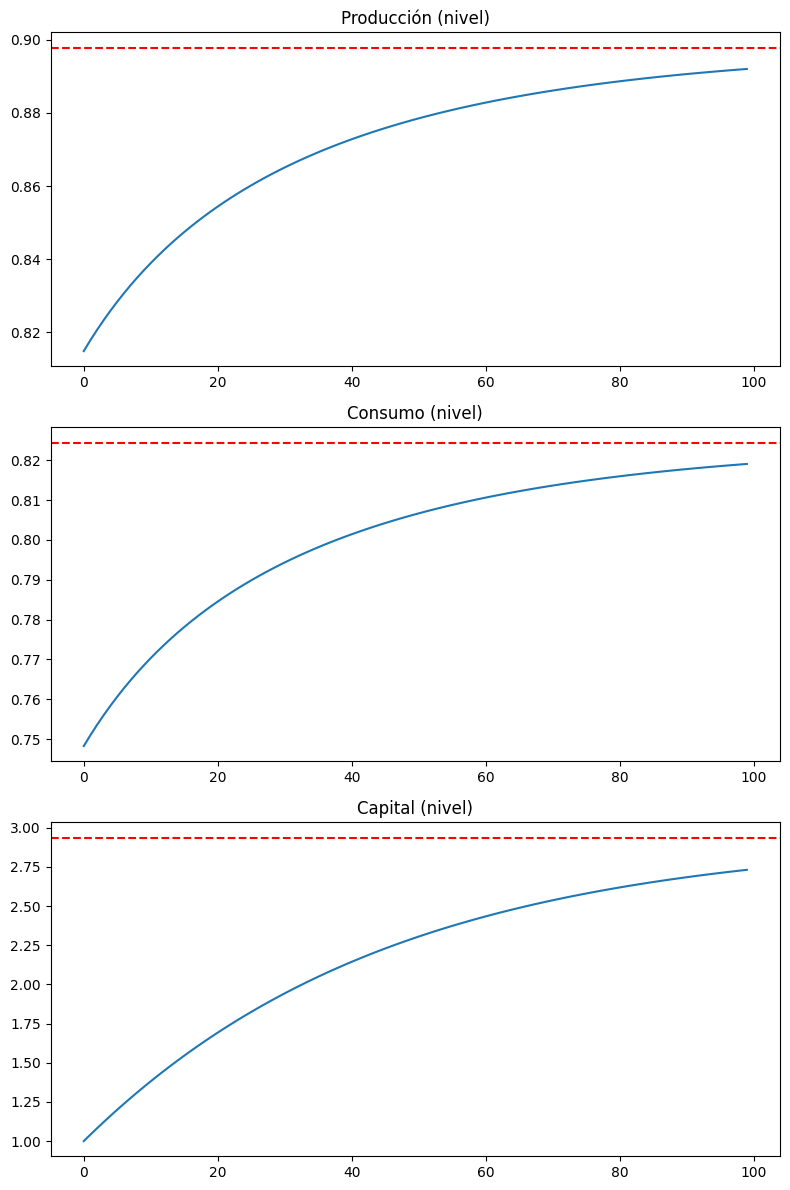

In [27]:
# Gráficos
# ============================================================================
fig, axs = plt.subplots(3, 1, figsize=(8, 12))

# Niveles
axs[0].plot(Y, label="Y")
axs[0].axhline(Y_ss, ls="--", c="r")
axs[0].set_title("Producción (nivel)")

axs[1].plot(C, label="C")
axs[1].axhline(C_ss, ls="--", c="r")
axs[1].set_title("Consumo (nivel)")

axs[2].plot(K, label="K")
axs[2].axhline(K_ss, ls="--", c="r")
axs[2].set_title("Capital (nivel)")
plt.tight_layout()
plt.show()

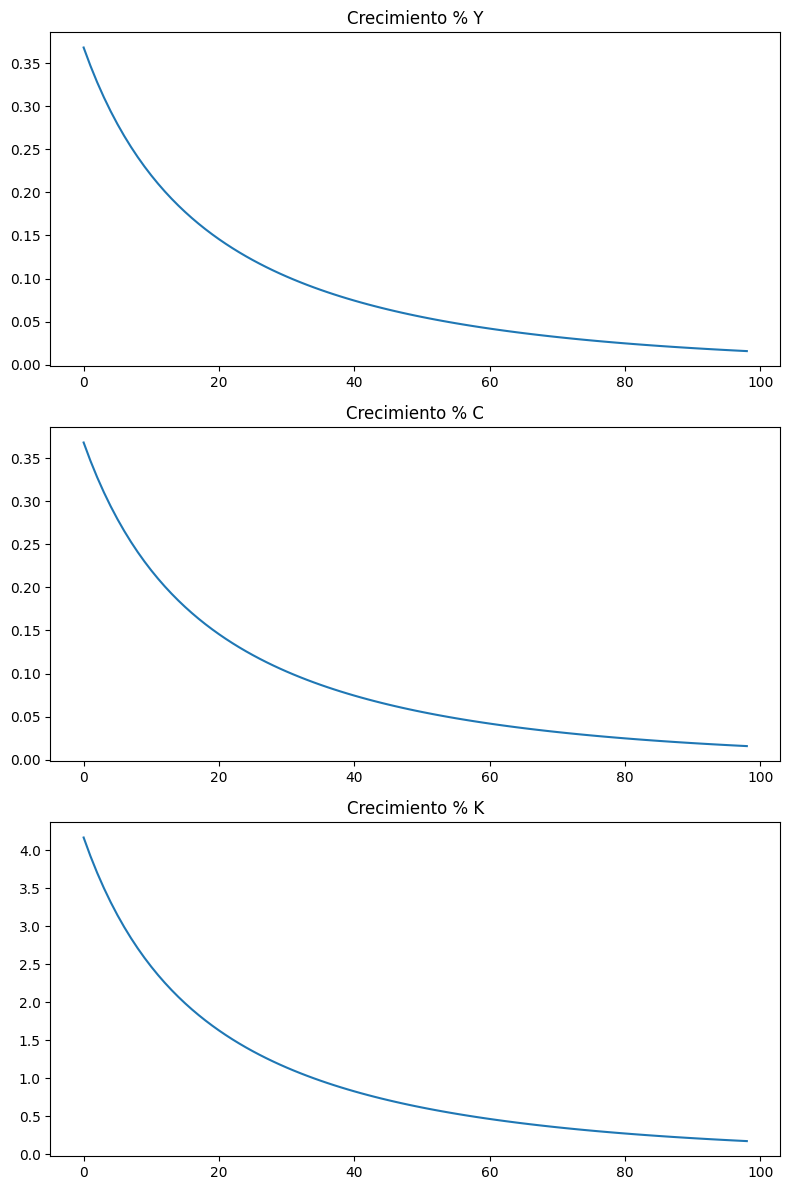

In [30]:
# Tasas de crecimiento
fig, axs = plt.subplots(3, 1, figsize=(8, 12))
axs[0].plot(gY*100)
axs[0].set_title("Crecimiento % Y")

axs[1].plot(gC*100)
axs[1].set_title("Crecimiento % C")

axs[2].plot(gK*100)
axs[2].set_title("Crecimiento % K")

plt.tight_layout()
plt.show()

## **2. Shock en K**

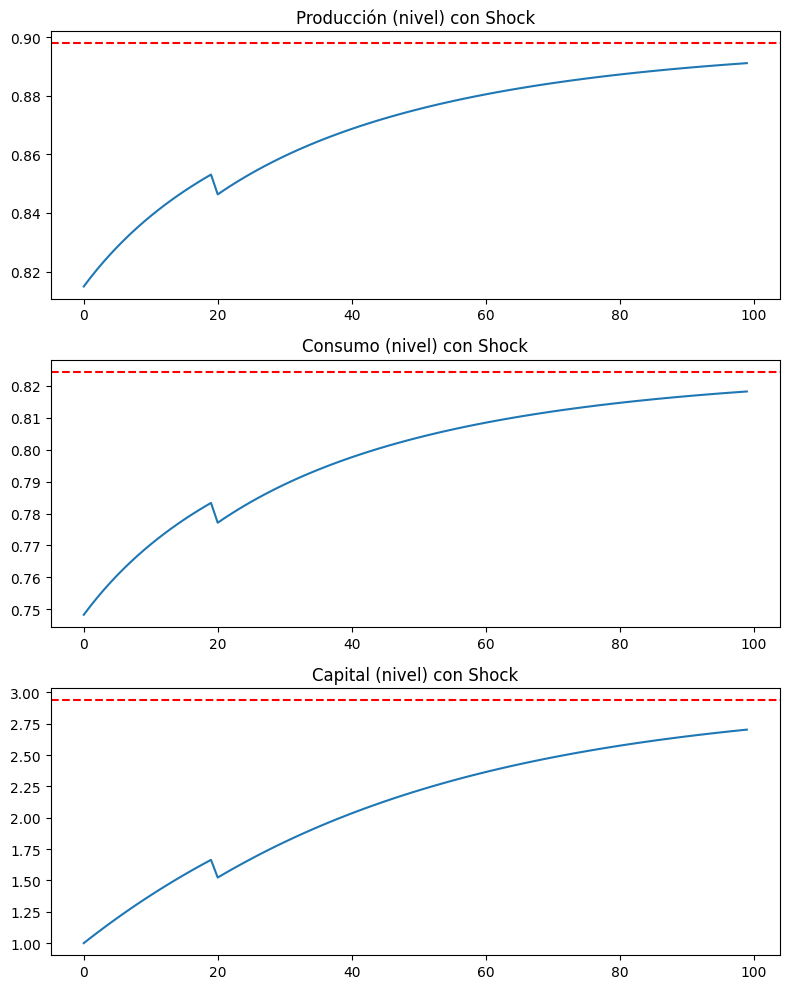

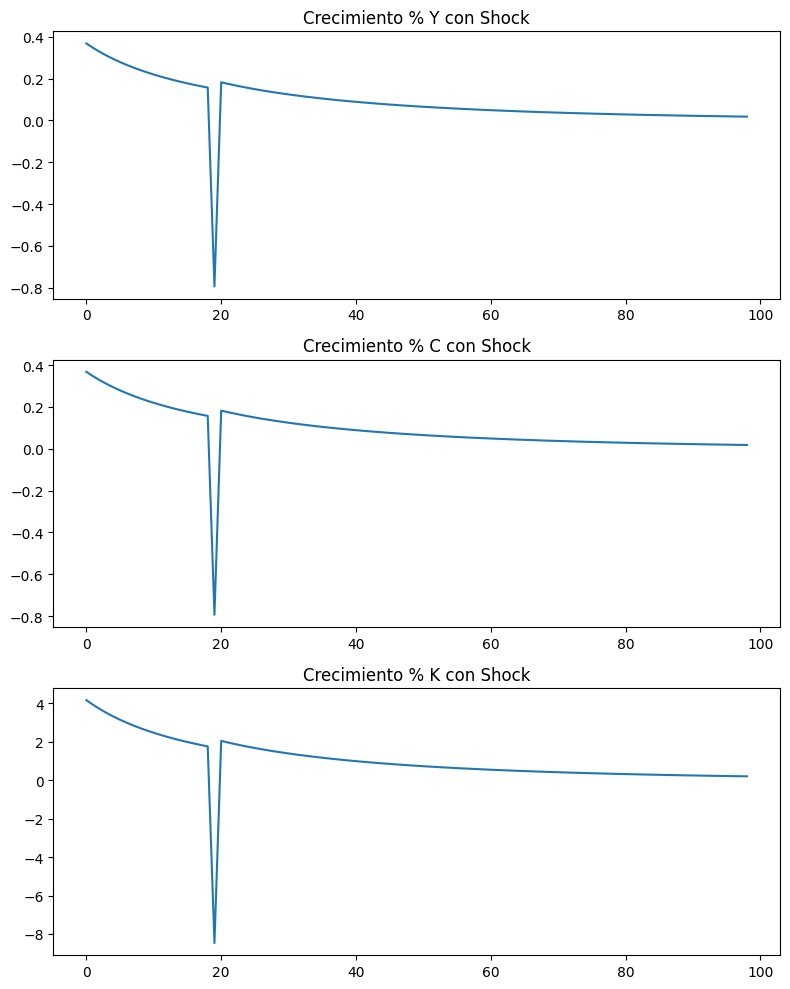

In [32]:
# Simulación de un Shock de Capital
# ===========================================================================

# Inicialización
T = 100
K_shock = np.zeros(T)
Y_shock = np.zeros(T)
C_shock = np.zeros(T)
I_shock = np.zeros(T)
L_shock = np.zeros(T)

# Condiciones iniciales (desviamos a K_ss)
K_shock[0] = K0
L_shock[:] = L_ss  # trabajo fijo de SS

shock_period = 20
shock_magnitude = 0.9 # Reduce capital by 10%

for t in range(T-1):
    # Apply shock
    if t == shock_period:
        K_shock[t] = K_shock[t] * shock_magnitude

    Y_shock[t] = A * (K_shock[t]**(1-alpha)) * (L_shock[t]**alpha)
    I_shock[t] = s * Y_shock[t]
    C_shock[t] = Y_shock[t] - I_shock[t]
    K_shock[t+1] = (1-delta)*K_shock[t] + I_shock[t]

# Último valor de producción y consumo
if T-1 == shock_period:
     K_shock[-1] = K_shock[-1] * shock_magnitude
Y_shock[-1] = A * (K_shock[-1]**(1-alpha)) * (L_shock[-1]**alpha)
I_shock[-1] = s * Y_shock[-1]
C_shock[-1] = Y_shock[-1] - I_shock[-1]


# Tasas de crecimiento con shock
def growth_rate(series):
    return (series[1:] - series[:-1]) / series[:-1]
gY_shock = growth_rate(Y_shock)
gC_shock = growth_rate(C_shock)
gK_shock = growth_rate(K_shock)


# Gráficos con Shock
# ============================================================================
fig, axs = plt.subplots(3, 1, figsize=(8, 10))

# Niveles
axs[0].plot(Y_shock, label="Y con Shock")
axs[0].axhline(Y_ss, ls="--", c="r")
axs[0].set_title("Producción (nivel) con Shock")

axs[1].plot(C_shock, label="C con Shock")
axs[1].axhline(C_ss, ls="--", c="r")
axs[1].set_title("Consumo (nivel) con Shock")

axs[2].plot(K_shock, label="K con Shock")
axs[2].axhline(K_ss, ls="--", c="r")
axs[2].set_title("Capital (nivel) con Shock")
plt.tight_layout()
plt.show()

# Tasas de crecimiento con shock
fig, axs = plt.subplots(3, 1, figsize=(8, 10))
axs[0].plot(gY_shock*100)
axs[0].set_title("Crecimiento % Y con Shock")

axs[1].plot(gC_shock*100)
axs[1].set_title("Crecimiento % C con Shock")

axs[2].plot(gK_shock*100)
axs[2].set_title("Crecimiento % K con Shock")

plt.tight_layout()
plt.show()